# Fault Subsection Demo

This notebook demonstrates the basic usage of `parserf` for exploring fault subsection data from earthquake rupture forecast models.

Topics covered:

1. Loading a `FaultModelDataset`
    - Explore dataset contents
2. Finding the nearest subsection by coordinates
3. Creating `FaultSubsection` instances
    - Accessing `FaultSubsectionData` properties (name, geometry, length, depth, dip, etc.)
    - Exploring `FaultSubsectionRuptures` (participating ruptures and cumulative MFD)
4. Using `FaultSubsectionData` and `FaultSubsectionRuptures` directly

## Imports

In [170]:
import matplotlib.pyplot as plt
import numpy as np

from parserf.models import FaultModel, FaultModelDataset
from parserf.subsection import FaultSubsection, FaultSubsectionData, FaultSubsectionRuptures

## 1. Loading a FaultModelDataset

`FaultModelDataset` is the entry point for all data access. It wraps a specific earthquake rupture forecast dataset and provides cached access to fault sections, parent IDs, and rupture scenarios.

Available fault models:
- `FaultModel.UCERF3_31` — UCERF3 fault model 3.1
- `FaultModel.UCERF3_32` — UCERF3 fault model 3.2
- `FaultModel.NSHMP_2023` — USGS NSHM CONUS v6.0.0

In [171]:
# Load the UCERF3 fault model 3.1 dataset
dataset = FaultModelDataset(FaultModel.UCERF3_31)
print("Dataset loaded:", dataset)

Dataset loaded: FaultModelDataset(model=<FaultModel.UCERF3_31: 31>)


### Explore dataset contents

The dataset exposes three main tables:
- `parent_ids` — maps fault names to their integer parent IDs
- `sections` — GeoDataFrame of all fault subsections with geometry and metadata
- `ruptures_parsed` — all rupture scenarios with parsed subsection index sets

In [172]:
# Parent fault names and IDs
print("Parent IDs shape:", dataset.parent_ids.shape)
dataset.parent_ids.head()

Parent IDs shape: (313, 2)


,parent_id,parent_name
0,1,Airport Lake
1,2,Almanor
2,3,Anacapa - Dume [1]
3,5,Anaheim
4,1000,Antelope Valley


In [173]:
# Fault subsections GeoDataFrame
print("Sections shape:", dataset.sections.shape)
print("Columns:", list(dataset.sections.columns))
dataset.sections.head()

Sections shape: (2606, 11)
Columns: ['name', 'state', 'states', 'index', 'parent-id', 'upper-depth', 'lower-depth', 'dip', 'dip-direction', 'aseismicity', 'geometry']


,name,state,states,index,parent-id,upper-depth,lower-depth,dip,dip-direction,aseismicity,geometry
0,Airport Lake (0),CA,None,0,1,0.0,13.0,50.0,89.459,0.1,"LINESTRING (-117.74953 35.74054, -117.76365 35..."
1,Airport Lake (1),CA,None,1,1,0.0,13.0,50.0,89.459,0.1,"LINESTRING (-117.76365 35.81038, -117.76492 35..."
2,Airport Lake (2),CA,None,2,1,0.0,13.0,50.0,89.459,0.1,"LINESTRING (-117.77588 35.88045, -117.78146 35..."
3,Airport Lake (3),CA,None,3,1,0.0,13.0,50.0,89.459,0.1,"LINESTRING (-117.77332 35.95033, -117.76387 35..."
4,Airport Lake (4),CA,None,4,1,0.0,13.0,50.0,89.459,0.1,"LINESTRING (-117.76413 36.02043, -117.76424 36..."


In [174]:
# Rupture scenarios
print("Ruptures shape:", dataset.ruptures_parsed.shape)
print("Columns:", list(dataset.ruptures_parsed.columns))
dataset.ruptures_parsed.head()

Ruptures shape: (253609, 8)
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'indices', 'parsed_indices']


,m,rate,depth,dip,width,rake,indices,parsed_indices
0,6.449,0.000034,1.3,50.0,15.273,-90.0,0:1,"{0, 1}"
1,6.638,0.000015,1.3,50.0,15.273,-90.0,0:2,"{0, 1, 2}"
2,6.780,0.000011,1.3,50.0,15.273,-90.0,0:3,"{0, 1, 2, 3}"
3,6.893,0.000007,1.3,50.0,15.273,-90.0,0:4,"{0, 1, 2, 3, 4}"
4,6.988,0.000040,1.3,50.0,15.273,-90.0,0:5,"{0, 1, 2, 3, 4, 5}"


## 2. Finding the Nearest Subsection by Coordinates

Use `dataset.nearest_index()` to find the closest fault subsection index for a given latitude and longitude. The returned index can be passed directly to `FaultSubsection`.

In [175]:
# Find the nearest subsection to a coordinate near Ridgecrest, CA
idx = dataset.nearest_index(lat=35.77, lon=-117.60)
print("Nearest index:", idx)

Nearest index: 1126


## 3. Creating a FaultSubsection Instance

`FaultSubsection` is a thin facade over a single subsection. It validates the index and then exposes two sub-objects:
- `.data` — local attributes (name, geometry, depths, dip, lengths, etc.)
- `.ruptures` — rupture participation data

In [176]:
sub = FaultSubsection(dataset, index=idx)
print(sub)

FaultSubsection(fault_model=UCERF3_31, index=1126, name='Little Lake (1)')


### Accessing FaultSubsectionData Properties

`sub.data` is a `FaultSubsectionData` object with properties for all subsection attributes.

In [177]:
# Basic identification
print("Index:      ", sub.data.index)
print("Name:       ", sub.data.name)
print("Parent ID:  ", sub.data.parent_id)
print("Parent Name:", sub.data.parent_name)

Index:       1126
Name:        Little Lake (1)
Parent ID:   145
Parent Name: Little Lake


In [178]:
# Fault geometry and dimensions
print("Geometry:     ", sub.data.geometry)
print("Length (km):  ", round(sub.data.length_km, 3))
print("Width (km):   ", round(sub.data.width_km, 3))
print("Area (km²):   ", round(sub.data.area_km2, 3))

Geometry:      LINESTRING (-117.68459 35.6526, -117.72173 35.70002)
Length (km):   6.244
Width (km):    13.0
Area (km²):    81.172


In [179]:
# Fault orientation and seismicity parameters
print("Upper depth (km):  ", sub.data.upper_depth_km)
print("Lower depth (km):  ", sub.data.lower_depth_km)
print("Dip (degrees):     ", sub.data.dip)
print("Dip direction:     ", sub.data.dip_direction)
print("Aseismicity factor:", sub.data.aseismicity)

Upper depth (km):   0.0
Lower depth (km):   13.0
Dip (degrees):      90.0
Dip direction:      56.915
Aseismicity factor: 0.1


### Exploring FaultSubsectionRuptures

`sub.ruptures` is a `FaultSubsectionRuptures` object with two properties:
- `participating_ruptures` — GeoDataFrame of all rupture scenarios involving this subsection; each
  row adds `length_km`, `area_km2`, `parent_area_pcts` (dict of parent fault → % of rupture area),
  and a merged surface-trace `geometry`
- `cumulative_mfd` — cumulative magnitude frequency distribution (i.e., exceedance rate)

In [180]:
# Participating ruptures: lazily computed and cached
participating = sub.ruptures.participating_ruptures
print("Number of participating ruptures:", len(participating))
print("Columns:", list(participating.columns))
participating.head()

Number of participating ruptures: 79
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'indices', 'parsed_indices', 'length_km', 'area_km2', 'parent_area_pcts', 'geometry']


,m,rate,depth,dip,width,rake,indices,parsed_indices,length_km,area_km2,parent_area_pcts,geometry
0,6.685,0.000005,1.3,65.1,13.922,-121.3,1:0-1127:1126,"{0, 1, 1126, 1127}",28.195931,428.906772,"{'Airport Lake': 62.145187252992315, 'Little L...","MULTILINESTRING ((-117.74953 35.74054, -117.76..."
1,6.773,0.000026,1.3,69.1,13.568,-132.4,1:0-1127:1125,"{0, 1, 1125, 1126, 1127}",34.440873,510.091015,"{'Airport Lake': 52.254383741719344, 'Little L...","MULTILINESTRING ((-117.74953 35.74054, -117.76..."
2,6.815,0.000004,1.3,61.5,14.242,-112.1,2:0-1127:1126,"{0, 1, 2, 1126, 1127}",36.049182,562.178743,"{'Airport Lake': 71.11917563336456, 'Little La...","MULTILINESTRING ((-117.74953 35.74054, -117.76..."
3,6.887,0.000022,1.3,65.1,13.922,-121.3,2:0-1127:1125,"{0, 1, 2, 1125, 1126, 1127}",42.294123,643.362986,"{'Airport Lake': 62.14483830810911, 'Little La...","MULTILINESTRING ((-117.74953 35.74054, -117.76..."
4,6.923,0.000009,1.3,59.3,14.440,-106.9,3:0-1127:1126,"{0, 1, 2, 3, 1126, 1127}",43.902365,695.449581,"{'Airport Lake': 76.65368422926072, 'Little La...","MULTILINESTRING ((-117.74953 35.74054, -117.76..."


In [181]:
# Examine the last rupture in detail
last_rup = participating.iloc[-1]

print("Subsection indices involved:", last_rup["parsed_indices"])
print("Total rupture length (km):  ", round(last_rup["length_km"], 2))
print("Total rupture area (km²):   ", round(last_rup["area_km2"], 2))
print("Parent fault area breakdown:")
for fault, pct in last_rup["parent_area_pcts"].items():
    print(f"  {fault}: {pct:.1f}%")
print("Geometry type:", last_rup["geometry"].geom_type)

Subsection indices involved: {1478, 1479, 1480, 2377, 1482, 2378, 1483, 1481, 1484, 1485, 1486, 1487, 1488, 1489, 1490, 1491, 1492, 1493, 1494, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 2411, 2412, 2413, 2414}
Total rupture length (km):   203.21
Total rupture area (km²):    2944.82
Parent fault area breakdown:
  Owens Valley: 49.5%
  Sierra Nevada (north): 10.3%
  Little Lake: 19.3%
  Sierra Nevada (south): 20.8%
Geometry type: MultiLineString


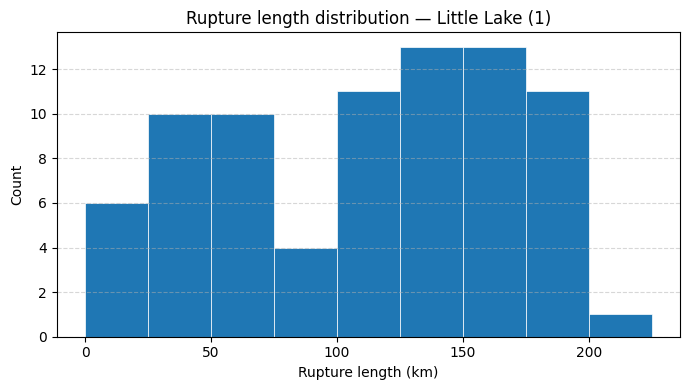

In [182]:
bin_width = 25  # km
lengths = participating["length_km"]
bins = np.arange(0, lengths.max() + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=bins, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Rupture length (km)")
ax.set_ylabel("Count")
ax.set_title(f"Rupture length distribution — {sub.data.name}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

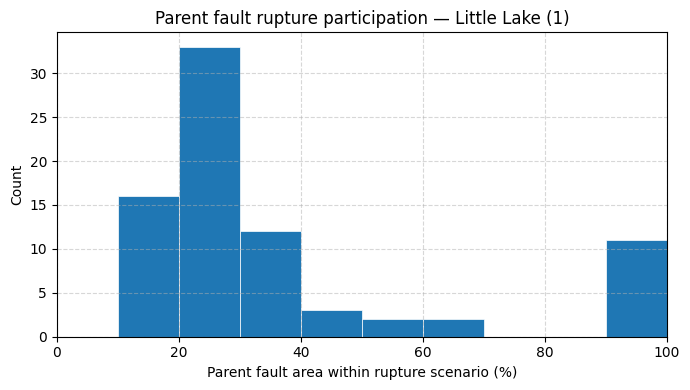

In [183]:
# Examine parent fault area participation percentages across all ruptures involving the subsection
def _parent_pct_cdf(subsection):
    """Return sorted pct values and cumulative probabilities for the subsection's parent fault."""
    parent = subsection.data.parent_name
    pcts = (
        subsection.ruptures.participating_ruptures["parent_area_pcts"]
        .apply(lambda d: d.get(parent, np.nan))
        .values
    )
    sorted_pcts = np.sort(pcts)
    cdf = np.arange(1, len(sorted_pcts) + 1) / len(sorted_pcts)
    return sorted_pcts, cdf


sorted_pcts, cdf = _parent_pct_cdf(sub)
bins = np.arange(0, 110, 10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sorted_pcts, bins=bins, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Parent fault area within rupture scenario (%)")
ax.set_ylabel("Count")
ax.set_title(f"Parent fault rupture participation — {sub.data.name}")
ax.set(xlim=(0, 100))
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [184]:
# Cumulative magnitude frequency distribution
mfd = sub.ruptures.cumulative_mfd
print(f"Unique magnitudes: {len(mfd)}  (from {len(participating)} ruptures)")
print(
    "Total exceedance rate (M ≥ {:.3f}): {:.3E}".format(
        mfd["magnitude"].iloc[0], mfd["cumulative_rate"].iloc[0]
    )
)
print(
    "Rate at largest rupture (M = {:.3f}):  {:.3E}".format(
        mfd["magnitude"].iloc[-1], mfd["cumulative_rate"].iloc[-1]
    )
)
mfd

Unique magnitudes: 71  (from 79 ruptures)
Total exceedance rate (M ≥ 6.233): 7.545E-04
Rate at largest rupture (M = 7.694):  4.710E-07


,magnitude,cumulative_rate
0,6.233,7.545385e-04
1,6.424,4.576232e-04
2,6.566,4.415105e-04
3,6.676,4.088783e-04
4,6.685,3.744082e-04
...,...,...
66,7.650,1.833614e-06
67,7.656,1.180407e-06
68,7.668,1.061166e-06
69,7.683,8.343078e-07


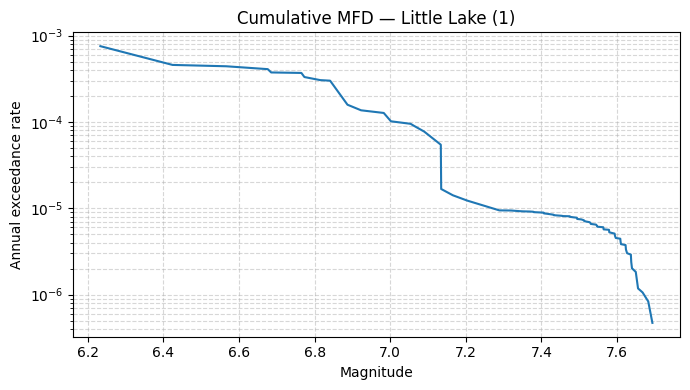

In [185]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(mfd["magnitude"], mfd["cumulative_rate"], linewidth=1.5)
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFD — {sub.data.name}")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Using FaultSubsectionData and FaultSubsectionRuptures Directly

You can also instantiate `FaultSubsectionData` and `FaultSubsectionRuptures` directly without going through `FaultSubsection`.

In [186]:
# Direct instantiation of FaultSubsectionData
data = FaultSubsectionData(dataset, index=idx)
print("Name via FaultSubsectionData:", data.name)
print("Length (km):", round(data.length_km, 3))

Name via FaultSubsectionData: Little Lake (1)
Length (km): 6.244


In [187]:
# Direct instantiation of FaultSubsectionRuptures
ruptures = FaultSubsectionRuptures(dataset, index=idx)
print("Participating ruptures count:", len(ruptures.participating_ruptures))

Participating ruptures count: 79
